In [1]:
#%%
"""
Compare measured temperatures with COMSOL temperatures.
"""

import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def spread_labels(y_values, min_gap=1.8):
    """
    Adjust y-positions so labels do not overlap.

    Parameters
    ----------
    y_values : array-like
        Original y-values for the labels.
    min_gap : float
        Minimum vertical spacing between labels.

    Returns
    -------
    adjusted : np.ndarray
        Adjusted y-positions.
    """
    y_values = np.array(y_values, dtype=float)
    adjusted = y_values.copy()

    order = np.argsort(adjusted)

    for i in range(1, len(order)):
        prev_idx = order[i - 1]
        curr_idx = order[i]

        if adjusted[curr_idx] - adjusted[prev_idx] < min_gap:
            adjusted[curr_idx] = adjusted[prev_idx] + min_gap

    return adjusted


def compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature"
):
    """
    Compare measured temperatures with COMSOL temperatures.

    Parameters
    ----------
    meas_file : str
        Path to measured CSV file.
    comsol_file : str
        Path to COMSOL CSV file.
    measurement_uncertainty : float, optional
        Uncertainty in measured values [Â°C]. Default is Â±2.5 Â°C.
    min_label_gap : float, optional
        Minimum vertical spacing between plot labels.

    Returns
    -------
    df : pandas.DataFrame
        Cleaned measurement dataframe.
    df_last60_avg : pandas.DataFrame
        Average of the last 60 measured values.
    df_60_before : pandas.DataFrame
        Measured values 60 samples before the end.
    df_meas_comsol : pandas.DataFrame
        COMSOL temperatures with mapped column names.
    df_diff : pandas.DataFrame
        Comparison dataframe.
    df_diff_T : pandas.DataFrame
        Transposed comparison dataframe.
    avg_ambient : float
        Average ambient temperature over last 240 samples.
    """

    column_mapping = {
        "Temperature (degC), Point: 37": "307 <Condcutor BL mid> (C)",
        "307 Temperature (degC) BL cond": "307 <Condcutor BL mid> (C)",
        "Temperature (degC), Point: 43": "308 <Jacket BL mid> (C)",
        "308 Temperature (degC) BL jacket": "308 <Jacket BL mid> (C)",
        "Temperature (degC), Point: 44": "309 <Air BL mid> (C)",
        "309 Temperature (degC) BL air": "309 <Air BL mid> (C)",
        "Temperature (degC), Point: 52": "310 <Condcutor TL mid> (C)",
        "310 Temperature (degC) TL cond": "310 <Condcutor TL mid> (C)",
        "Temperature (degC), Point: 58": "311 <Jacket TL mid> (C)",
        "311 Temperature (degC) TL jacket": "311 <Jacket TL mid> (C)",
        "Temperature (degC), Point: 59": "312 <Air TL mid> (C)",
        "312 Temperature (degC) TL air": "312 <Air TL mid> (C)",
        "Temperature (degC), Point: 106": "303 <Conductor BR mid> (C)",
        "303 Temperature (degC) BR cond": "303 <Conductor BR mid> (C)",
        "Temperature (degC), Point: 112": "304 <Jacket BR mid> (C)",
        "304 Temperature (degC) BR jacket": "304 <Jacket BR mid> (C)",
        "Temperature (degC), Point: 113": "305 <Air BR mid> (C)",
        "305 Temperature (degC) BR air": "305 <Air BR mid> (C)"
    }

    measurement_cols = [
        '303 <Conductor BR mid> (C)',
        '304 <Jacket BR mid> (C)',
        '305 <Air BR mid> (C)',
        '307 <Condcutor BL mid> (C)',
        '308 <Jacket BL mid> (C)',
        '309 <Air BL mid> (C)',
        '310 <Condcutor TL mid> (C)',
        '311 <Jacket TL mid> (C)',
        '312 <Air TL mid> (C)',
        '313 <Top of multiduct inside material> (C)',
        '314 <Air ambient> (C)'
    ]

    # -------------------------------------------------------------------------
    # Read measurement data
    # -------------------------------------------------------------------------
    df_raw = pd.read_csv(
        meas_file,
        encoding='utf-16',
        sep=',',
        skiprows=26
    )

    df = df_raw[[col for col in measurement_cols if col in df_raw.columns]]

    # -------------------------------------------------------------------------
    # Plot measurement data with non-overlapping labels
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 6))
    max_value = df.max().max()
    cols = list(df.columns)

    for col in cols:
        plt.plot(df.index, df[col], label=col)

    # Last values
    last_idx = df.index[-1]
    label_x_offset = 12
    right_grid_padding = 60
    last_values = [df[col].iloc[-1] for col in cols]
    adjusted_last_y = spread_labels(last_values, min_gap=min_label_gap)

    for col, y_point, y_text in zip(cols, last_values, adjusted_last_y):
        plt.plot(last_idx, y_point, marker='o', markersize=8, color='black')
        plt.annotate(
            f"{y_point:.1f} °C",
            xy=(last_idx, y_point),
            xytext=(last_idx + label_x_offset, y_text),
            textcoords='data',
            fontsize=10,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )

    plt.xlabel("Time [minutes]")
    plt.ylabel("Temperature [°C]")
    plt.title(title)
    plt.ylim(15, max(max_value + 5, max(adjusted_last_y) + 2))
    plt.xlim(df.index.min(), df.index.max() + right_grid_padding)
    plt.xticks(np.arange(df.index.min(), df.index.max() + right_grid_padding + 1, 60))
    plt.grid(True)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    if title == "Temperature 520 A":
        col = "304 <Jacket BR mid> (C)"
        if col in df.columns:
            max_idx = df[col].idxmax()
            max_val = df[col].max()
            plt.plot(max_idx, max_val, marker='x', markersize=10, color='black')
            plt.annotate(
                f"{max_val:.1f} °C",
                xy=(max_idx, max_val),
                xytext=(max_idx, max_val - 5),
                textcoords='data',
                fontsize=10,
                ha='center',
                va='top',
                arrowprops=dict(arrowstyle='-', color='black', lw=1)
            )
    plt.show()

    # -------------------------------------------------------------------------
    # Average ambient temperature over last 240 samples
    # -------------------------------------------------------------------------
    avg_ambient = None
    ambient_col = '314 <Air ambient> (C)'

    if ambient_col in df_raw.columns:
        avg_ambient = df_raw[ambient_col].iloc[-240:].mean()

    # -------------------------------------------------------------------------
    # Average of last 60 samples
    # -------------------------------------------------------------------------
    df_last60_avg = pd.DataFrame(
        [df.iloc[-60:].mean()],
        index=['Measured_avg_last_60']
    )

    df_60_before = pd.DataFrame(
        [df.iloc[-61]],
        index=['Measured_60_before_end']
    )

    # -------------------------------------------------------------------------
    # Read COMSOL data
    # -------------------------------------------------------------------------
    with open(comsol_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    header_line = lines[4].lstrip('%').strip()
    data_line = lines[5].strip()

    headers = next(csv.reader([header_line]))
    values = [float(v) for v in next(csv.reader([data_line]))]

    df_meas_comsol = pd.DataFrame([values], columns=headers)
    df_meas_comsol = df_meas_comsol.rename(columns=column_mapping)
    df_meas_comsol.index = ['COMSOL']

    # -------------------------------------------------------------------------
    # Keep only common columns
    # -------------------------------------------------------------------------
    common_cols = df_last60_avg.columns.intersection(df_meas_comsol.columns)

    df_diff = pd.concat(
        [
            df_last60_avg[common_cols],
            df_meas_comsol[common_cols]
        ],
        axis=0
    )

    df_diff.index = ['Measured_avg_last_60', 'COMSOL']

    df_diff.loc['Measured_lower'] = (
        df_diff.loc['Measured_avg_last_60'] - measurement_uncertainty
    )

    df_diff.loc['Measured_upper'] = (
        df_diff.loc['Measured_avg_last_60'] + measurement_uncertainty
    )

    df_diff.loc['Difference'] = (
        df_diff.loc['Measured_avg_last_60'] - df_diff.loc['COMSOL']
    )

    df_diff = df_diff.loc[
        [
            'Measured_avg_last_60',
            'Measured_lower',
            'Measured_upper',
            'COMSOL',
            'Difference'
        ]
    ]

    df_diff_T = df_diff.T

    # Round to 1 decimal place for better readability
    df_last60_avg = df_last60_avg.round(1)
    df_60_before = df_60_before.round(1)
    df_meas_comsol = df_meas_comsol.round(1)
    df_diff = df_diff.round(1)
    df_diff_T = df_diff_T.round(1)
    if avg_ambient is not None:
        avg_ambient = round(avg_ambient, 1)

    return (
        df,
        df_last60_avg,
        df_60_before,
        df_meas_comsol,
        df_diff,
        df_diff_T,
        avg_ambient
    )




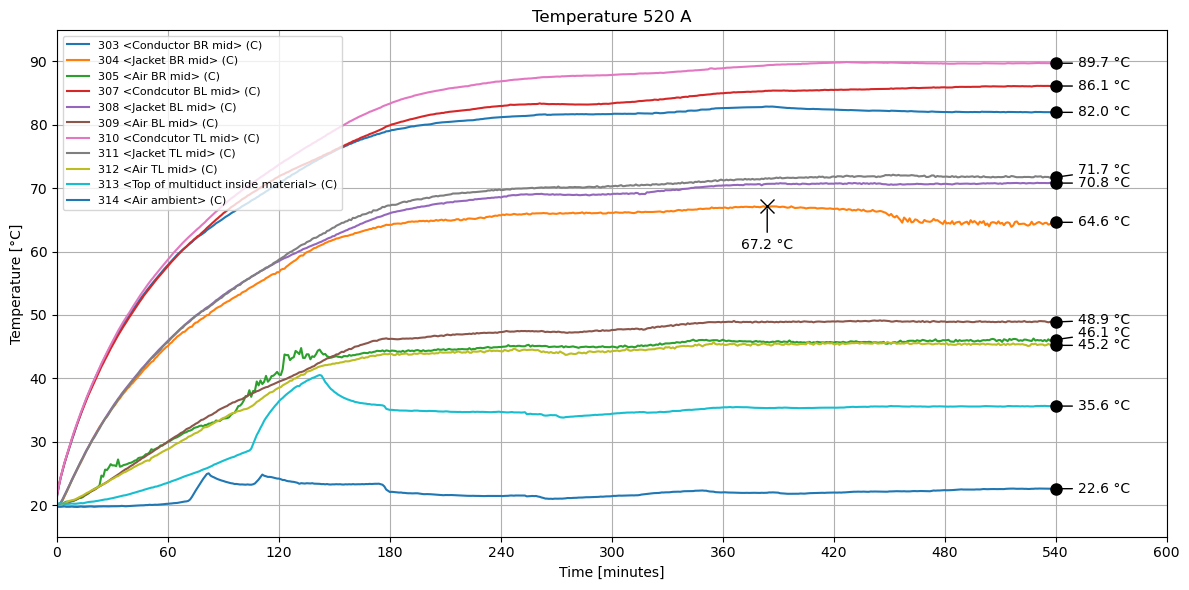

Average ambient temperature:
22.1

Comparison table:
                      303 <Conductor BR mid> (C)  304 <Jacket BR mid> (C)  \
Measured_avg_last_60                        82.0                     64.5   
Measured_lower                              79.5                     62.0   
Measured_upper                              84.5                     67.0   
COMSOL                                      83.2                     68.3   
Difference                                  -1.2                     -3.8   

                      305 <Air BR mid> (C)  307 <Condcutor BL mid> (C)  \
Measured_avg_last_60                  46.0                        86.1   
Measured_lower                        43.5                        83.6   
Measured_upper                        48.5                        88.6   
COMSOL                                46.8                        86.0   
Difference                            -0.8                         0.1   

                      308 <Jacket BL mi

In [2]:
# -------------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------------
meas_file = "520 A black tape on jacket conductor good setup.csv"
comsol_file = "520A temp from comsol.csv"

(
    df,
    df_last60_avg,
    df_60_before,
    df_meas_comsol,
    df_diff,
    df_diff_T,
    avg_ambient
) = compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature 520 A"
)

print("Average ambient temperature:")
print(avg_ambient)

print("\nComparison table:")
print(df_diff)

print("\nTransposed comparison table:")
print(df_diff_T)

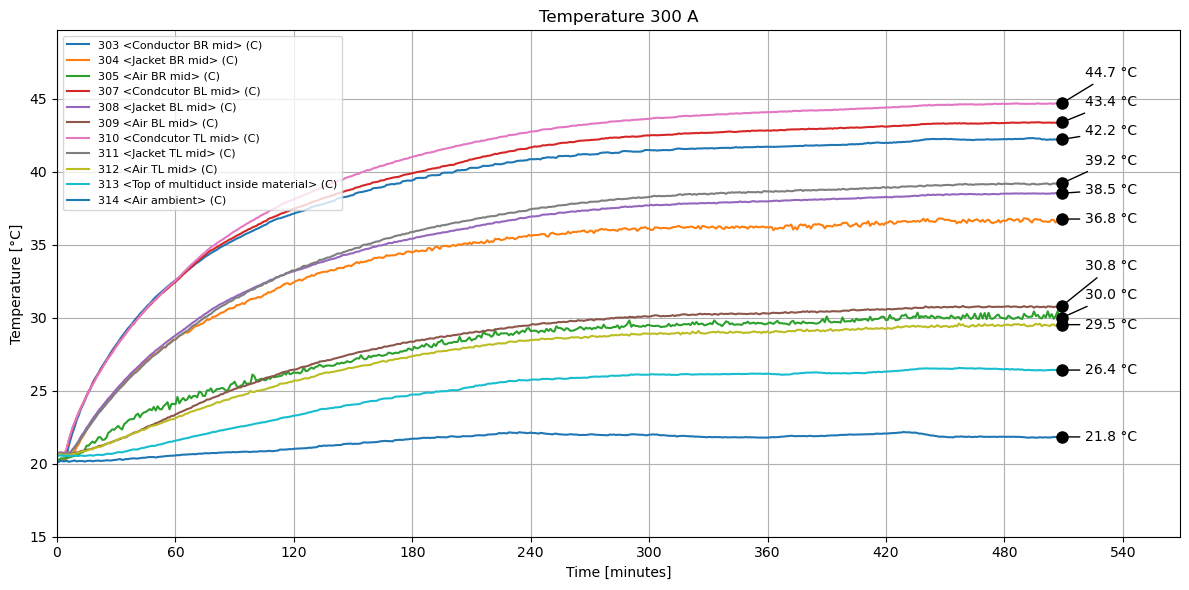

Average ambient temperature for 300A:
21.9

Comparison table for 300A:
                      303 <Conductor BR mid> (C)  304 <Jacket BR mid> (C)  \
Measured_avg_last_60                        42.2                     36.7   
Measured_lower                              39.7                     34.2   
Measured_upper                              44.7                     39.2   
COMSOL                                      41.2                     37.0   
Difference                                   1.0                     -0.3   

                      305 <Air BR mid> (C)  307 <Condcutor BL mid> (C)  \
Measured_avg_last_60                  30.1                        43.3   
Measured_lower                        27.6                        40.8   
Measured_upper                        32.6                        45.8   
COMSOL                                29.6                        42.0   
Difference                             0.5                         1.3   

                     

In [3]:
# -------------------------------------------------------------------------
# Example usage for 300A
# -------------------------------------------------------------------------
meas_file = "300 A black tape on jacket conductor good setup.csv"
comsol_file = "300A temp from comsol.csv"

(
    df_300,
    df_last60_avg_300,
    df_60_before_300,
    df_meas_comsol_300,
    df_diff_300,
    df_diff_T_300,
    avg_ambient_300
) = compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature 300 A"
)

print("Average ambient temperature for 300A:")
print(avg_ambient_300)

print("\nComparison table for 300A:")
print(df_diff_300)

print("\nTransposed comparison table for 300A:")
print(df_diff_T_300)

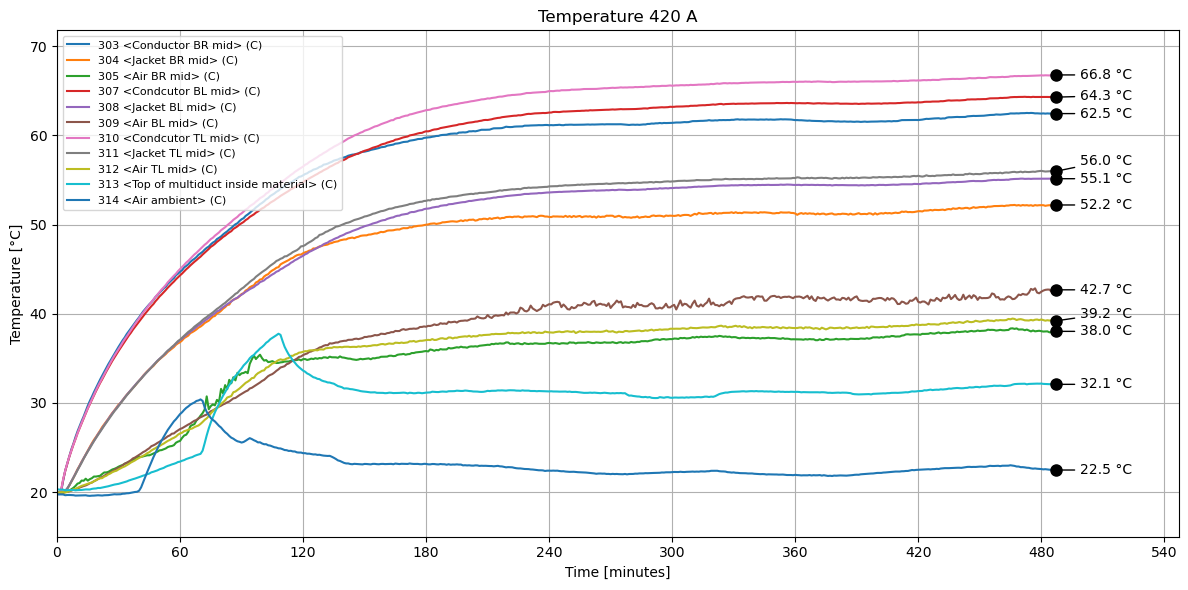

Average ambient temperature for 420A:
22.3

Comparison table for 420A:
                      303 <Conductor BR mid> (C)  304 <Jacket BR mid> (C)  \
Measured_avg_last_60                        62.3                     52.0   
Measured_lower                              59.8                     49.5   
Measured_upper                              64.8                     54.5   
COMSOL                                      60.9                     51.9   
Difference                                   1.4                      0.1   

                      305 <Air BR mid> (C)  307 <Condcutor BL mid> (C)  \
Measured_avg_last_60                  38.1                        64.1   
Measured_lower                        35.6                        61.6   
Measured_upper                        40.6                        66.6   
COMSOL                                37.8                        62.2   
Difference                             0.3                         1.9   

                     

In [4]:
# -------------------------------------------------------------------------
# Example usage for 420A
# -------------------------------------------------------------------------
meas_file = "420 A black tape on jacket conductor at ends not properly drilled into.csv"
comsol_file = "420A temp from comsol.csv"

(
    df_420,
    df_last60_avg_420,
    df_60_before_420,
    df_meas_comsol_420,
    df_diff_420,
    df_diff_T_420,
    avg_ambient_420
) = compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature 420 A"
)

print("Average ambient temperature for 420A:")
print(avg_ambient_420)

print("\nComparison table for 420A:")
print(df_diff_420)

print("\nTransposed comparison table for 420A:")
print(df_diff_T_420)

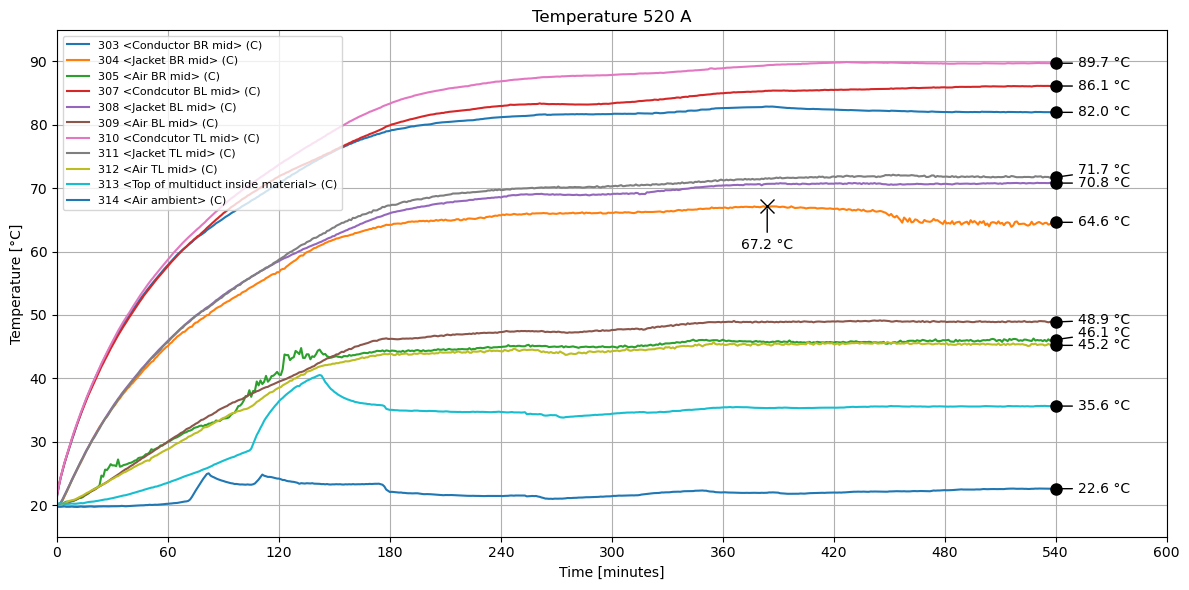

Average ambient temperature for 520A:
22.1

Comparison table for 520A:
                      303 <Conductor BR mid> (C)  304 <Jacket BR mid> (C)  \
Measured_avg_last_60                        82.0                     64.5   
Measured_lower                              79.5                     62.0   
Measured_upper                              84.5                     67.0   
COMSOL                                      83.2                     68.3   
Difference                                  -1.2                     -3.8   

                      305 <Air BR mid> (C)  307 <Condcutor BL mid> (C)  \
Measured_avg_last_60                  46.0                        86.1   
Measured_lower                        43.5                        83.6   
Measured_upper                        48.5                        88.6   
COMSOL                                46.8                        86.0   
Difference                            -0.8                         0.1   

                     

In [5]:
# -------------------------------------------------------------------------
# Example usage for 520A
# -------------------------------------------------------------------------
meas_file = "520 A black tape on jacket conductor good setup.csv"
comsol_file = "520A temp from comsol.csv"

(
    df_520,
    df_last60_avg_520,
    df_60_before_520,
    df_meas_comsol_520,
    df_diff_520,
    df_diff_T_520,
    avg_ambient_520
) = compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature 520 A"
)

print("Average ambient temperature for 520A:")
print(avg_ambient_520)

print("\nComparison table for 520A:")
print(df_diff_520)

print("\nTransposed comparison table for 520A:")
print(df_diff_T_520)

In [6]:
# Check columns in 420 A CSV
df_raw_420 = pd.read_csv("420 A black tape on jacket conductor at ends not properly drilled into.csv", encoding='utf-16', sep=',', skiprows=26)
print("Columns in 420 A CSV:")
print(list(df_raw_420.columns))

# Check columns in 520 A CSV
df_raw_520 = pd.read_csv("520 A black tape on jacket conductor good setup.csv", encoding='utf-16', sep=',', skiprows=26)
print("\nColumns in 520 A CSV:")
print(list(df_raw_520.columns))

Columns in 420 A CSV:
['Scan', 'Time', '101 <Air left> (C)', '102 <Air mid opposite side of 309> (C)', '103 <Air right> (C)', '301 <Conductor top right side> (C)', '302 <Jacket top right side> (C)', '303 <Conductor BR mid> (C)', '304 <Jacket BR mid> (C)', '305 <Air BR mid> (C)', '307 <Condcutor BL mid> (C)', '308 <Jacket BL mid> (C)', '309 <Air BL mid> (C)', '310 <Condcutor TL mid> (C)', '311 <Jacket TL mid> (C)', '312 <Air TL mid> (C)', '313 <Top of multiduct inside material> (C)', '314 <Air ambient> (C)', '315 <Jacket top left side> (C)', '316 <Conductor top left side> (C)']

Columns in 520 A CSV:
['Scan', 'Time', '101 <Jacket top left side> (C)', '102 <Conductor top left side> (C)', '103 <Air left> (C)', '201 <Jacket top right side> (C)', '202 <Conductor top right side> (C)', '301 <Air roof> (C)', '303 <Conductor BR mid> (C)', '304 <Jacket BR mid> (C)', '305 <Air BR mid> (C)', '307 <Condcutor BL mid> (C)', '308 <Jacket BL mid> (C)', '309 <Air BL mid> (C)', '310 <Condcutor TL mid> (C

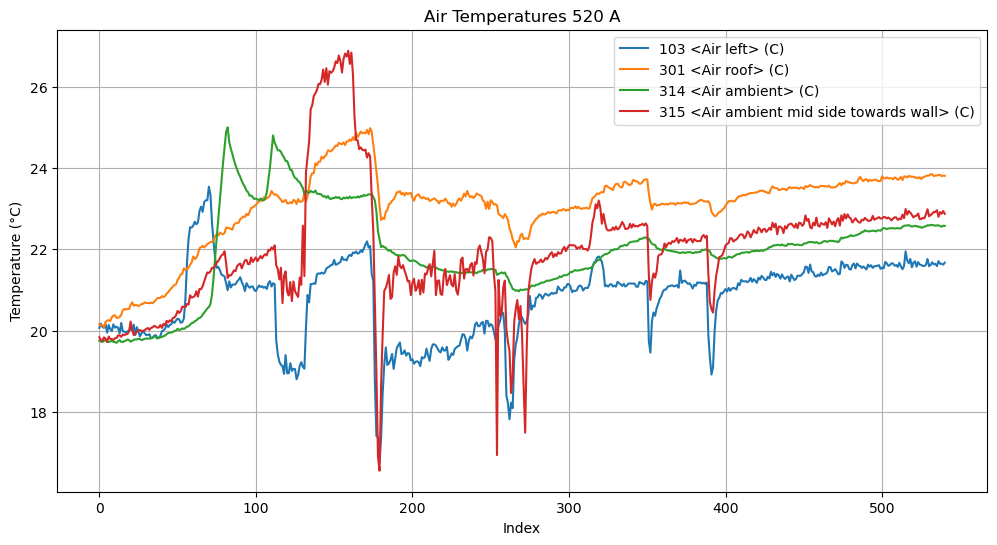

In [7]:
# Plot air measurements for 520 A
#drop columns 305, 309, 312

air_cols = [col for col in df_raw_520.columns if 'Air' in col and col not in ['305 <Air BR mid> (C)', '309 <Air BL mid> (C)', '312 <Air TL mid> (C)']]

plt.figure(figsize=(12, 6))
for col in air_cols:
    plt.plot(df_raw_520.index, df_raw_520[col], label=col)

plt.xlabel("Index")
plt.ylabel("Temperature (°C)")
plt.title("Air Temperatures 520 A")
plt.legend()
plt.grid(True)
plt.show()

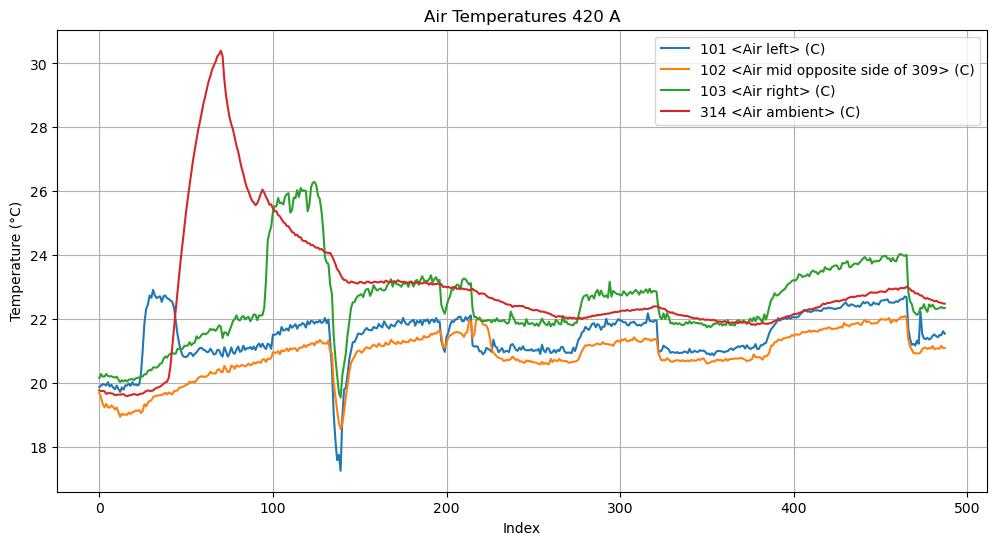

In [8]:
# Plot air measurements for 420 A
#drop columns 305, 309, 312
air_cols = [col for col in df_raw_420.columns if 'Air' in col and col not in ['305 <Air BR mid> (C)', '309 <Air BL mid> (C)', '312 <Air TL mid> (C)']]

plt.figure(figsize=(12, 6))
for col in air_cols:
    plt.plot(df_raw_420.index, df_raw_420[col], label=col)

plt.xlabel("Index")
plt.ylabel("Temperature (°C)")
plt.title("Air Temperatures 420 A")
plt.legend()
plt.grid(True)
plt.show()

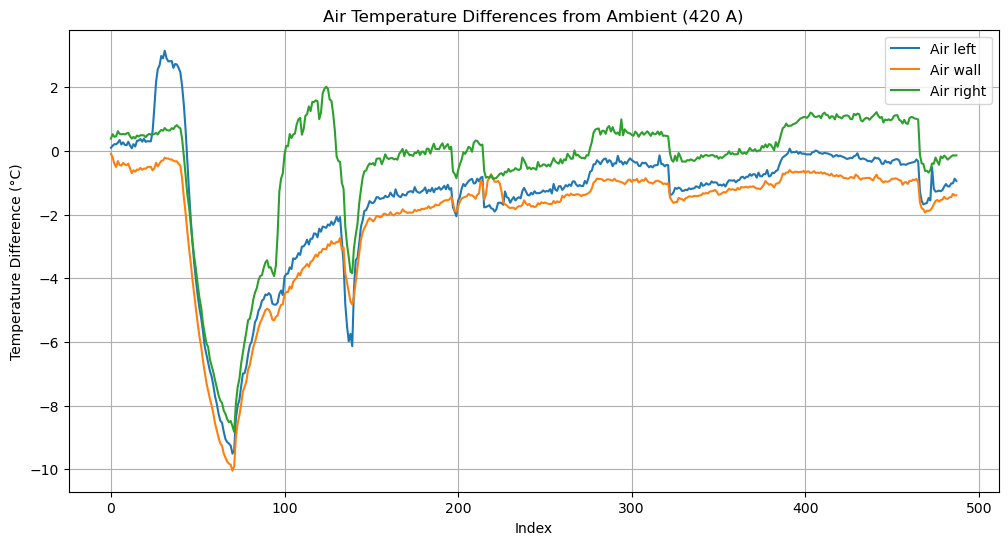

In [9]:
# Plot differences for 420 A: (101, 102, 103) - 314
differences_420 = {
    'Air left': df_raw_420['101 <Air left> (C)'] - df_raw_420['314 <Air ambient> (C)'],
    'Air wall': df_raw_420['102 <Air mid opposite side of 309> (C)'] - df_raw_420['314 <Air ambient> (C)'],
    'Air right': df_raw_420['103 <Air right> (C)'] - df_raw_420['314 <Air ambient> (C)']
}

plt.figure(figsize=(12, 6))
for label, diff in differences_420.items():
    plt.plot(df_raw_420.index, diff, label=label)

plt.xlabel("Index")
plt.ylabel("Temperature Difference (°C)")
plt.title("Air Temperature Differences from Ambient (420 A)")
plt.legend()
plt.grid(True)
plt.show()

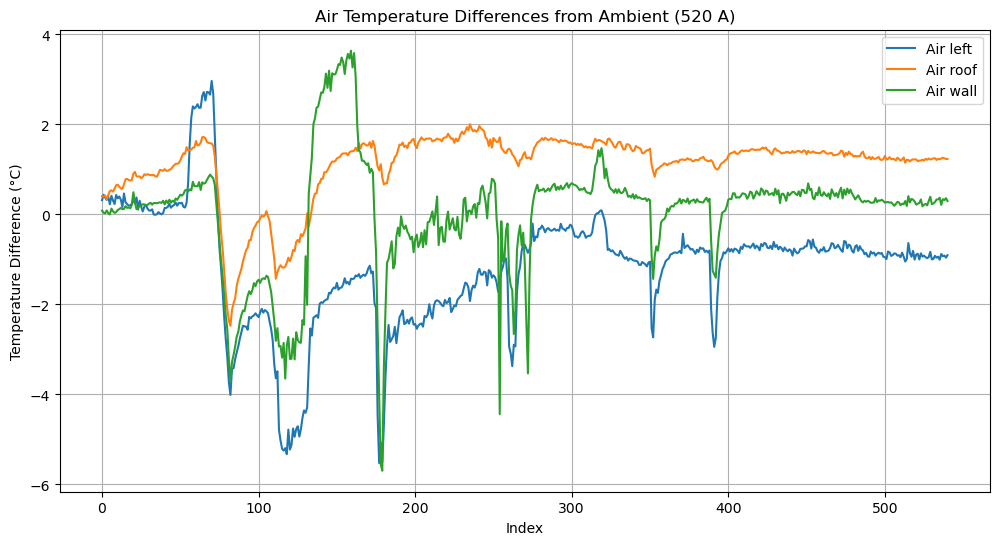

In [10]:
# Plot differences for 520 A: (103, 301, 315) - 314
differences_520 = {
    'Air left': df_raw_520['103 <Air left> (C)'] - df_raw_520['314 <Air ambient> (C)'],
    'Air roof': df_raw_520['301 <Air roof> (C)'] - df_raw_520['314 <Air ambient> (C)'],
    'Air wall': df_raw_520['315 <Air ambient mid side towards wall> (C)'] - df_raw_520['314 <Air ambient> (C)']
}

plt.figure(figsize=(12, 6))
for label, diff in differences_520.items():
    plt.plot(df_raw_520.index, diff, label=label)

plt.xlabel("Index")
plt.ylabel("Temperature Difference (°C)")
plt.title("Air Temperature Differences from Ambient (520 A)")
plt.legend()
plt.grid(True)
plt.show()

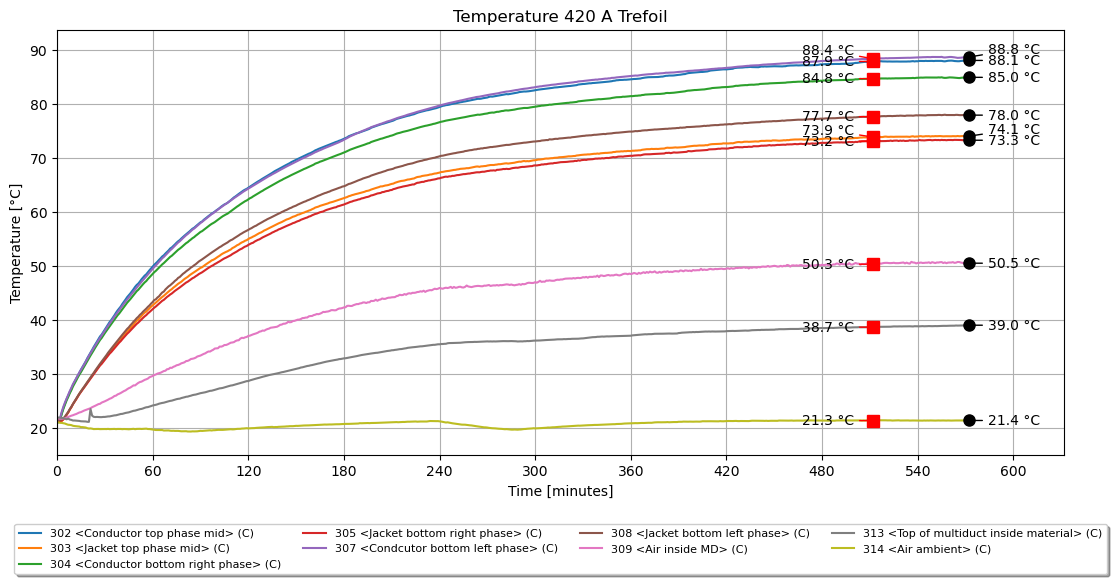

Average ambient temperature for 420 A trefoil:
21.343349999999997


In [29]:
# -------------------------------------------------------------------------
# Process 420 A trefoil measurements (without COMSOL)
# -------------------------------------------------------------------------
meas_file = "420 A trefoil.csv"

# Load measurement data
df_raw_420_trefoil = pd.read_csv(
    meas_file,
    encoding='utf-16',
    sep=',',
    skiprows=24
)

# Keep all columns
df_420_trefoil = df_raw_420_trefoil

# Downsample to every 6th index (10s to 60s resolution)
df_420_trefoil = df_420_trefoil.iloc[::6].reset_index(drop=True)

# Plot measurement data (only temperature columns)
temp_cols = [col for col in df_420_trefoil.columns if '(C)' in col]
temp_cols = [col for col in temp_cols if not col.startswith(('315 ', '301 ', '201 ', '202 ', '103 ', '102 ', '101 '))]
plt.figure(figsize=(12, 6))
max_value = df_420_trefoil[temp_cols].max().max()
cols = temp_cols

for col in cols:
    plt.plot(df_420_trefoil.index, df_420_trefoil[col], label=col)

# Last values
last_idx = df_420_trefoil.index[-1]
label_x_offset = 12
right_grid_padding = 60
last_values = [df_420_trefoil[col].iloc[-1] for col in cols]
adjusted_last_y = spread_labels(last_values, min_gap=2.0)

for col, y_point, y_text in zip(cols, last_values, adjusted_last_y):
    plt.plot(last_idx, y_point, marker='o', markersize=8, color='black')
    plt.annotate(
        f"{y_point:.1f} °C",
        xy=(last_idx, y_point),
        xytext=(last_idx + label_x_offset, y_text),
        textcoords='data',
        fontsize=10,
        ha='left',
        va='center',
        arrowprops=dict(arrowstyle='-', color='black', lw=1)
    )

# Values 60 indexes prior
prior_idx = df_420_trefoil.index[-61]
prior_values = [df_420_trefoil[col].iloc[-61] for col in cols]
adjusted_prior_y = spread_labels(prior_values, min_gap=2.0)

for col, y_point, y_text in zip(cols, prior_values, adjusted_prior_y):
    plt.plot(prior_idx, y_point, marker='s', markersize=8, color='red')
    plt.annotate(
        f"{y_point:.1f} °C",
        xy=(prior_idx, y_point),
        xytext=(prior_idx - label_x_offset, y_text),
        textcoords='data',
        fontsize=10,
        ha='right',
        va='center',
        arrowprops=dict(arrowstyle='-', color='red', lw=1)
    )

plt.xlabel("Time [minutes]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature 420 A Trefoil")
plt.ylim(15, max(max_value + 5, max(adjusted_last_y) + 2, max(adjusted_prior_y) + 2))
plt.xlim(df_420_trefoil.index.min(), df_420_trefoil.index.max() + right_grid_padding)
plt.xticks(np.arange(df_420_trefoil.index.min(), df_420_trefoil.index.max() + right_grid_padding + 1, 60))
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

# Average ambient temperature over last 240 samples
avg_ambient_420_trefoil = None
ambient_col = '314 <Air ambient> (C)'

if ambient_col in df_raw_420_trefoil.columns:
    avg_ambient_420_trefoil = df_raw_420_trefoil[ambient_col].iloc[-240:].mean()

# Average of last 60 samples (temperature columns only)
df_last60_avg_420_trefoil = pd.DataFrame(
    [df_420_trefoil[temp_cols].iloc[-60:].mean()],
    index=['Measured_avg_last_60']
).round(1)

# Values 60 samples before end (temperature columns only)
df_60_before_420_trefoil = pd.DataFrame(
    [df_420_trefoil[temp_cols].iloc[-61]],
    index=['Measured_60_before_end']
).round(1)

print("Average ambient temperature for 420 A trefoil:")
print(avg_ambient_420_trefoil)

print("\nAverage of last 60 samples for 420 A trefoil:")
print(df_last60_avg_420_trefoil)

print("\nValues 60 samples before end for 420 A trefoil:")
print(df_60_before_420_trefoil)

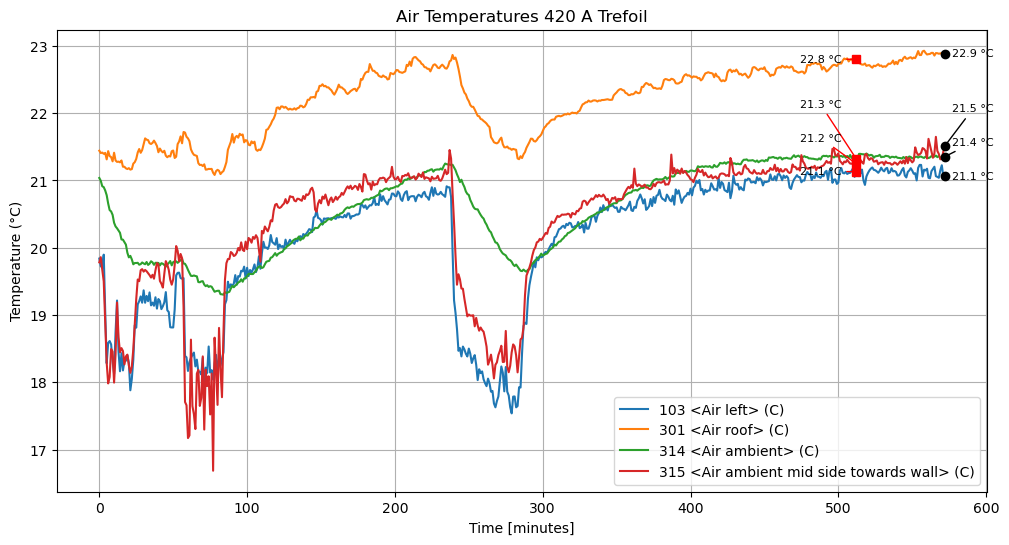

Average of last 60 samples for air temperatures 420 A trefoil:
                      103 <Air left> (C)  301 <Air roof> (C)  \
Measured_avg_last_60                21.1                22.8   

                      314 <Air ambient> (C)  \
Measured_avg_last_60                   21.4   

                      315 <Air ambient mid side towards wall> (C)  
Measured_avg_last_60                                         21.3  


In [27]:
# Plot air temperatures for 420 A trefoil
air_cols = [col for col in df_420_trefoil.columns if 'Air' in col and col.startswith(('315 ', '301 ', '201 ', '202 ', '103 ', '102 ', '101 ', '314 '))]

plt.figure(figsize=(12, 6))
for col in air_cols:
    plt.plot(df_420_trefoil.index, df_420_trefoil[col], label=col)

# Markers at last index
last_idx = df_420_trefoil.index[-1]
last_values = [df_420_trefoil[col].iloc[-1] for col in air_cols]
adjusted_last_y = spread_labels(last_values, min_gap=0.5)

for col, y_point, y_text in zip(air_cols, last_values, adjusted_last_y):
    plt.plot(last_idx, y_point, marker='o', markersize=6, color='black')
    plt.annotate(
        f"{y_point:.1f} °C",
        xy=(last_idx, y_point),
        xytext=(last_idx + 5, y_text),
        textcoords='data',
        fontsize=8,
        ha='left',
        va='center',
        arrowprops=dict(arrowstyle='-', color='black', lw=1)
    )

# Markers 60 indexes prior
prior_idx = df_420_trefoil.index[-61]
prior_values = [df_420_trefoil[col].iloc[-61] for col in air_cols]
adjusted_prior_y = spread_labels(prior_values, min_gap=0.5)

for col, y_point, y_text in zip(air_cols, prior_values, adjusted_prior_y):
    plt.plot(prior_idx, y_point, marker='s', markersize=6, color='red')
    plt.annotate(
        f"{y_point:.1f} °C",
        xy=(prior_idx, y_point),
        xytext=(prior_idx - 10, y_text),
        textcoords='data',
        fontsize=8,
        ha='right',
        va='center',
        arrowprops=dict(arrowstyle='-', color='red', lw=1)
    )

plt.xlabel("Time [minutes]")
plt.ylabel("Temperature (°C)")
plt.title("Air Temperatures 420 A Trefoil")
plt.legend()
plt.grid(True)
plt.show()

# Average of last 60 samples for air temperatures
df_last60_avg_air = pd.DataFrame(
    [df_420_trefoil[air_cols].iloc[-60:].mean()],
    index=['Measured_avg_last_60']
).round(1)

print("Average of last 60 samples for air temperatures 420 A trefoil:")
print(df_last60_avg_air)